X_train shape: (3200, 29)
Logistic Regression training finished.
Accuracy Logistic Regression (main): 0.865


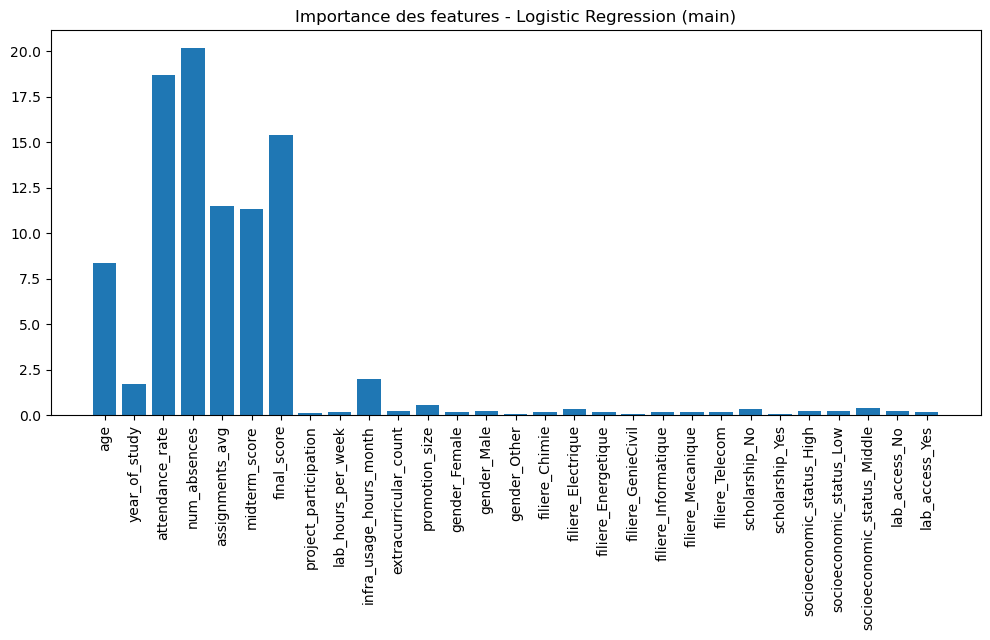

Accuracy Decision Tree: 0.89375


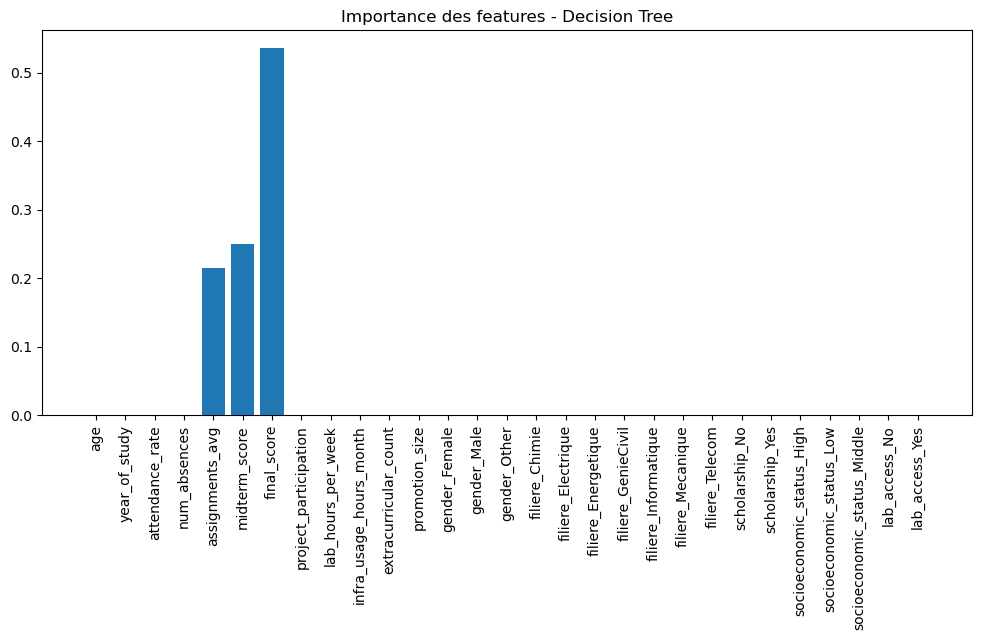

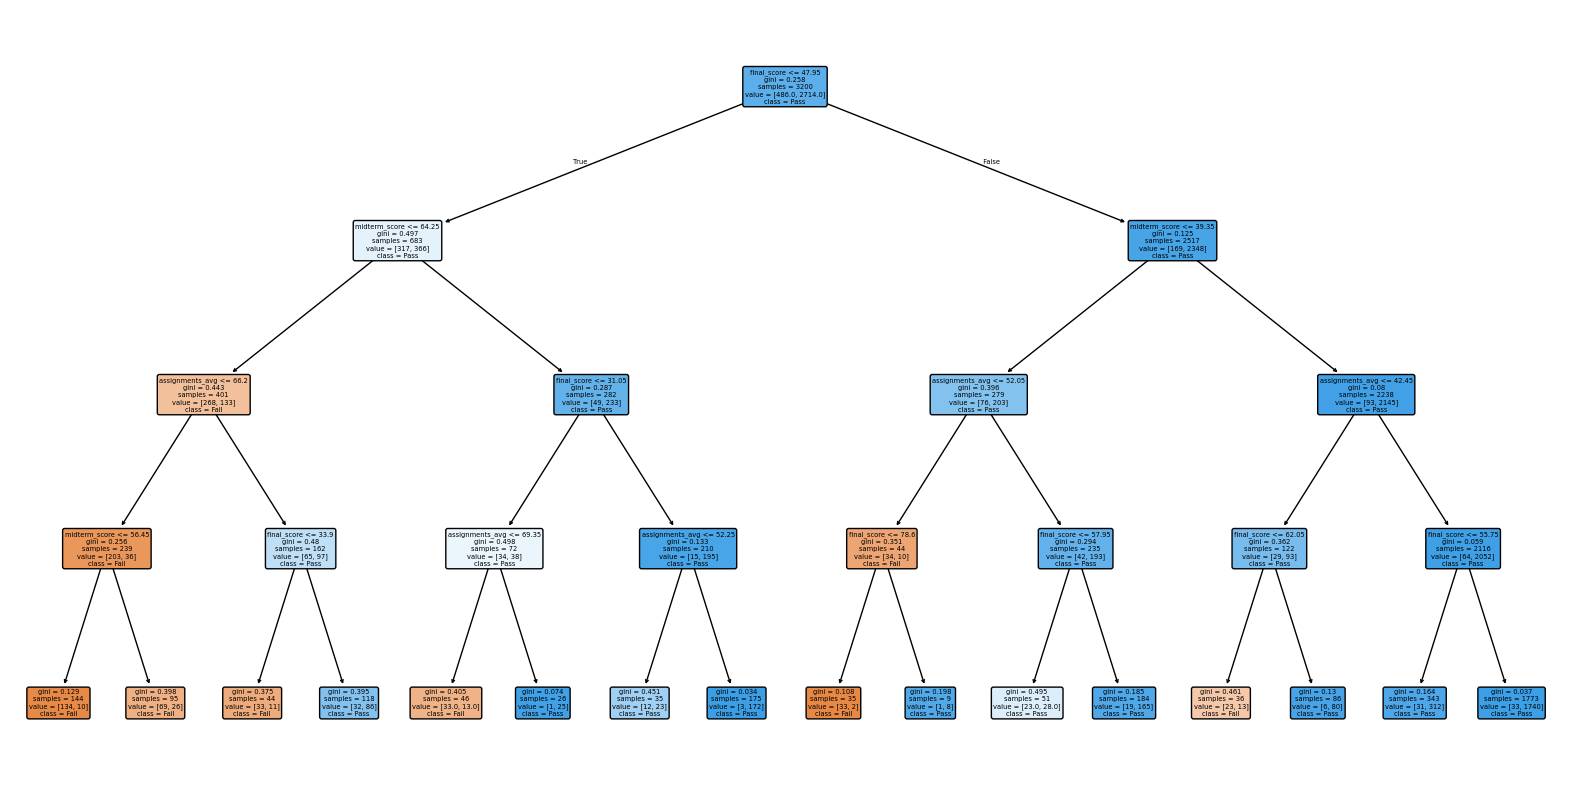

Accuracy Logistic Regression (main): 0.8650
Accuracy Decision Tree: 0.8938


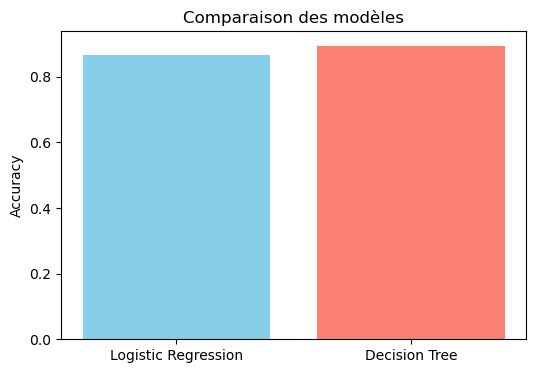

In [1]:
cimport pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Préparer les données
# -----------------------------
df = pd.read_csv("X_train.csv")
y = pd.read_csv("y_train.csv").values.ravel()

# Supprimer les colonnes inutiles
cols_to_drop = [ "supervisor_assigned", "classroom_allocated"]
df.drop(columns=cols_to_drop, inplace=True)

# Colonnes catégorielles à encoder
cat_cols = ["gender", "filiere", "scholarship", "socioeconomic_status", "lab_access"]
df_encoded = pd.get_dummies(df, columns=cat_cols)

# Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(df_encoded.values, y, test_size=0.2, random_state=42)
feature_names = df_encoded.columns
print("X_train shape:", X_train.shape)

# -----------------------------
# 2️⃣ Logistic Regression codée à la main
# -----------------------------
class LogisticRegressionManual:
    def __init__(self, learningrate=0.1, iterations=1000):
        self.lr = learningrate
        self.iterations = iterations
        self.weights = None
        self.costhistory = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1/(1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        m, n = X.shape
        self.weights = np.zeros(n)
        for i in range(self.iterations):
            z = X @ self.weights
            y_pred = self.sigmoid(z)
            cost = -(1/m)*np.sum(y*np.log(y_pred + 1e-15) + (1-y)*np.log(1 - y_pred + 1e-15))
            self.costhistory.append(cost)
            gradient = (1/m)*(X.T @ (y_pred - y))
            self.weights -= self.lr * gradient
        print("Logistic Regression training finished.")

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        return self.sigmoid(X @ self.weights)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# Entraîner le modèle manuel
log_model = LogisticRegressionManual(learningrate=0.1, iterations=1000)
log_model.fit(X_train, y_train)

# Prédictions et accuracy
y_pred_log = log_model.predict(X_test)
acc_log = np.mean(y_pred_log == y_test)
print("Accuracy Logistic Regression (main):", acc_log)

# Graphique des importances des features (valeurs absolues des poids)
importance_log = np.abs(log_model.weights)
plt.figure(figsize=(12,5))
plt.bar(range(len(importance_log)), importance_log)
plt.xticks(range(len(importance_log)), feature_names, rotation=90)
plt.title("Importance des features - Logistic Regression (main)")
plt.show()

# -----------------------------
# 3️⃣ Arbre de décision
# -----------------------------
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
acc_tree = np.mean(y_pred_tree == y_test)
print("Accuracy Decision Tree:", acc_tree)

# Importance des features - arbre
importance_tree = tree_model.feature_importances_
plt.figure(figsize=(12,5))
plt.bar(range(len(importance_tree)), importance_tree)
plt.xticks(range(len(importance_tree)), feature_names, rotation=90)
plt.title("Importance des features - Decision Tree")
plt.show()

# Visualisation de l'arbre
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=feature_names, class_names=["Fail","Pass"], filled=True, rounded=True)
plt.show()

# -----------------------------
# 4️⃣ Comparaison finale
# -----------------------------
print(f"Accuracy Logistic Regression (main): {acc_log:.4f}")
print(f"Accuracy Decision Tree: {acc_tree:.4f}")

plt.figure(figsize=(6,4))
plt.bar(["Logistic Regression", "Decision Tree"], [acc_log, acc_tree], color=["skyblue", "salmon"])
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles")
plt.show()


✅ Données chargées

📊 Comparaison des performances :

                  Modèle  Accuracy  Precision  Recall  F1-Score  AUC-ROC  \
0  Régression Logistique      87.4      87.09  100.00      0.93     0.60   
1      Arbre de Décision      91.5      94.22   95.88      0.95     0.92   

   Temps d'entraînement (s)  
0                      0.22  
1                      0.02  


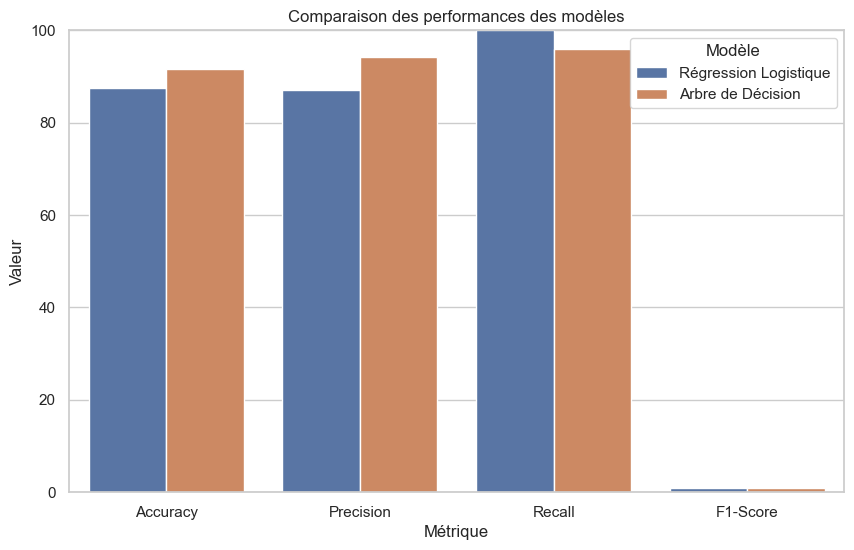

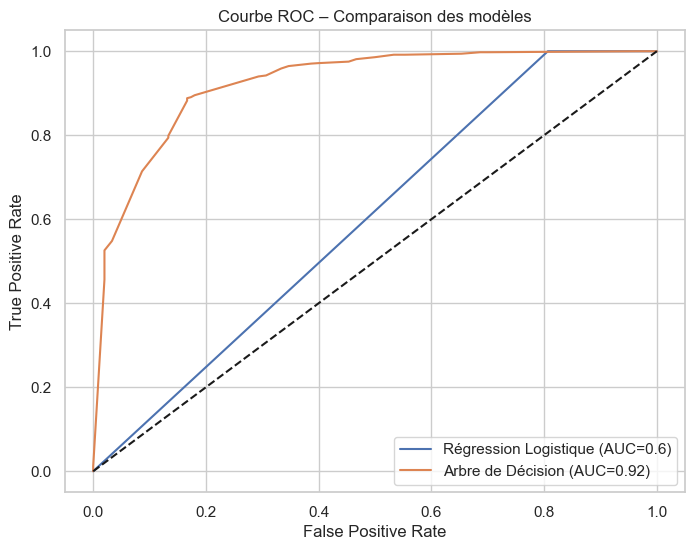

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# ------------------------------------------------
# 1️⃣ Chargement des datasets
# ------------------------------------------------
X_train = pd.read_csv("X_train.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values
y_train = pd.read_csv("y_train.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.ravel()

X_test = pd.read_csv("X_test.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values
y_test = pd.read_csv("y_test.csv").apply(pd.to_numeric, errors='coerce').fillna(0).values.ravel()

print("✅ Données chargées")

# ------------------------------------------------
# 2️⃣ Régression Logistique (manuelle)
# ------------------------------------------------
class LogisticRegression:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        for _ in range(self.iterations):
            z = X @ self.weights
            y_pred = self.sigmoid(z)
            gradient = (1/m) * (X.T @ (y_pred - y))
            self.weights -= self.lr * gradient

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# ----- Évaluation avec temps d'entraînement -----
def evaluate_model(model, name, X_train, y_train, X_test, y_test, is_custom=False):
    start_time = time.time()
    if is_custom:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    end_time = time.time()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    metrics = {
        "Modèle": name,
        "Accuracy": round(accuracy_score(y_test, y_pred)*100,2),
        "Precision": round(precision_score(y_test, y_pred)*100,2),
        "Recall": round(recall_score(y_test, y_pred)*100,2),
        "F1-Score": round(f1_score(y_test, y_pred),2),
        "AUC-ROC": round(auc_score,2),
        "Temps d'entraînement (s)": round(end_time - start_time,2)
    }
    return metrics, fpr, tpr

# ------------------------------------------------
# 3️⃣ Instanciation et évaluation des modèles
# ------------------------------------------------
log_model = LogisticRegression(learning_rate=0.1, iterations=1000)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

log_metrics, fpr_log, tpr_log = evaluate_model(log_model, "Régression Logistique", X_train, y_train, X_test, y_test, is_custom=True)
tree_metrics, fpr_tree, tpr_tree = evaluate_model(tree_model, "Arbre de Décision", X_train, y_train, X_test, y_test)

# ----- Création du tableau comparatif -----
df_results = pd.DataFrame([log_metrics, tree_metrics])
print("\n📊 Comparaison des performances :\n")
print(df_results)

# ------------------------------------------------
# 4️⃣ Graphiques
# ------------------------------------------------
sns.set(style="whitegrid")

# 4.1️⃣ Barplot des métriques principales
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
df_melt = df_results.melt(id_vars="Modèle", value_vars=metrics_to_plot, var_name="Métrique", value_name="Valeur")

plt.figure(figsize=(10,6))
sns.barplot(data=df_melt, x="Métrique", y="Valeur", hue="Modèle")
plt.title("Comparaison des performances des modèles")
plt.ylim(0, 100)
plt.show()

# 4.2️⃣ Courbes ROC
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Régression Logistique (AUC={log_metrics["AUC-ROC"]})')
plt.plot(fpr_tree, tpr_tree, label=f'Arbre de Décision (AUC={tree_metrics["AUC-ROC"]})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC – Comparaison des modèles")
plt.legend()
plt.show()
